# BGL — log anomaly detection with the Anomaly Detection Framework (ADF)

This notebook runs the Anomaly Detection Framework (ADF) end to end on **BGL**, the public log of
the BlueGene/L supercomputer: 4,747,963 lines from 69,252 nodes over seven months, with every line
labelled normal or alert.

| Chapter | What happens |
|---|---|
| 0 | Setup — working folder, dataset, configuration, choices |
| 1 | Data — the raw log → one table of lines |
| 2 | Split — chronological, and windows built within each node |
| 3 | Drain — log lines → templates |
| 4 | Embeddings — the sentence transformer |
| 5 | Windows — template ids for every window, and a vector for every template |
| 6 | Autoencoder — an LSTM autoencoder learns what a normal window looks like |
| 7 | Scoring and evaluation — every test line gets a verdict |

**Result on the test lines** (949,593 lines, 46,365 of them anomalous):

| Precision | Recall | F1 |
|---|---|---|
| 0.98449 | 0.98184 | 0.98317 |

### Two ways to run it

Every parameter behind this result is in `config.yaml` next to this notebook, and everything that
takes long to compute is in `artifacts/`: the fitted Drain parser, the template embeddings and the
trained autoencoder.

- **Reproduce the result** — the default. Chapters 3–6 load the shipped artefacts and chapter 7
  recomputes every score from the raw log. Section 7.4 compares the outcome with `config.yaml`.
  The whole notebook takes a few minutes.
- **Train your own model** — switch the choices in 0.2. Chapters 3–6 then fit the parser,
  fine-tune the embeddings and train the autoencoder with the parameters from `config.yaml`, or
  with your own.

---
## 0 — Setup

### 0.1 What you need

1. **A working folder.** Everything this notebook produces is written there. Set `WORK_DIR` in the
   next cell; the folder is created if it does not exist.
2. **The dataset.** Download `bgl2.gz` from the USENIX Computer Failure Data Repository —
   <https://www.usenix.org/cfdr-data>, entry *BlueGene/L*, direct link
   <http://0b4af6cdc2f0c5998459-c0245c5c937c5dedcca3f1764ecc9b2f.r43.cf2.rackcdn.com/hpc4/bgl2.gz> —
   and decompress it into `WORK_DIR/data/`:
   ```bash
   gunzip -c bgl2.gz > WORK_DIR/data/bgl2
   ```
   The file is checked against the checksum in `config.yaml`.
3. **The base sentence transformer** — needed only when you fine-tune the embeddings yourself:
   [`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)
   at the revision pinned in `config.yaml`. Chapter 4 downloads it into `WORK_DIR/models/`.
4. **The Python environment of this repository.** In the repository root, with
   [uv](https://docs.astral.sh/uv/):
   ```bash
   uv sync --locked --extra deploy
   uv run --with jupyter jupyter lab
   ```

### 0.2 Choices

Three switches decide what is loaded and what is recomputed:

| Switch | `"ours"` | the alternative |
|---|---|---|
| `DRAIN` | load the shipped parser | `"fit"` — fit Drain on the training and validation lines |
| `EMBEDDINGS` | load the shipped template embeddings | `"finetune"` — fine-tune the sentence transformer here |
| `AUTOENCODER` | load the shipped model | `"train"` — train with the parameters in `config.yaml` |

With all three set to `"ours"` the notebook reproduces the published numbers exactly. What to
expect from the other combinations:

- **`DRAIN = "fit"`**. The fit is deterministic and yields the shipped parser: 3.3 compares the two
  template by template.
- **`EMBEDDINGS = "finetune"`**. The fine-tuning is deterministic too, and 5.2 compares the result
  with the shipped embeddings. On the hardware the result was produced on — Apple Silicon, with the
  environment in `uv.lock` — they are identical.
- **`AUTOENCODER = "train"`**. Training on Apple Silicon (MPS) is not deterministic, so a model
  trained here scores slightly differently from the shipped one, and 7.3 chooses its threshold
  afresh on the training and validation lines. Expect numbers close to the published ones, not
  identical. Training takes about two hours.

In [1]:
from __future__ import annotations

import hashlib
import json
import logging
import shutil
import time
import warnings
from pathlib import Path

import numpy as np
import polars as pl
import torch
import yaml

# Progress bars fall back to plain text when ipywidgets is not installed; the notice is noise.
warnings.filterwarnings("ignore", message="IProgress not found")

# -------------------------------------------------------------------------------------------
# YOUR SETTINGS
# -------------------------------------------------------------------------------------------
WORK_DIR = Path.home() / "adf_demos" / "bgl"    # any folder you like; created if missing

DRAIN = "ours"          # "ours" | "fit"
EMBEDDINGS = "ours"     # "ours" | "finetune"
AUTOENCODER = "ours"    # "ours" | "train"
# -------------------------------------------------------------------------------------------

DEMO_DIR = Path.cwd()                  # the folder that holds this notebook
ARTIFACTS = DEMO_DIR / "artifacts"
CONFIG = yaml.safe_load((DEMO_DIR / "config.yaml").read_text())

DATA_DIR = WORK_DIR / "data"
MODELS_DIR = WORK_DIR / "models"
WORK_DIR.mkdir(parents=True, exist_ok=True)

assert DRAIN in ("ours", "fit"), DRAIN
assert EMBEDDINGS in ("ours", "finetune"), EMBEDDINGS
assert AUTOENCODER in ("ours", "train"), AUTOENCODER
REPRODUCE = (DRAIN, EMBEDDINGS, AUTOENCODER) == ("ours", "ours", "ours")


def show(path: Path) -> str:
    """A path for printing — relative to WORK_DIR or to this notebook's folder."""
    path = Path(path)
    for root, name in ((WORK_DIR, "WORK_DIR"), (DEMO_DIR, ".")):
        if path == root:
            return name
        try:
            return f"{name}/{path.relative_to(root)}"
        except ValueError:
            pass
    return str(path).replace(str(Path.home()), "~")


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 24), b""):
            digest.update(chunk)
    return digest.hexdigest()


# The dataset — the decompressed file must be exactly the published one.
LOG_PATH = DATA_DIR / CONFIG["dataset"]["decompressed"]["file"]
assert LOG_PATH.exists(), f"{show(LOG_PATH)} not found — download {CONFIG['dataset']['url']} and decompress it"
assert sha256(LOG_PATH) == CONFIG["dataset"]["decompressed"]["sha256"], f"{show(LOG_PATH)} is not the published file"
print(f"dataset    {show(LOG_PATH):<34} checksum OK")

# The shipped artefacts — each must match the checksum recorded in config.yaml.
for spec in CONFIG["artifacts"].values():
    assert sha256(DEMO_DIR / spec["file"]) == spec["sha256"], f"{spec['file']} does not match config.yaml"
print(f"artefacts  {len(CONFIG['artifacts'])} files in ./artifacts, checksums OK")

for name in ("adf.core.common.logger", "adf.logs.parsers.drain.drain"):
    logging.getLogger(name).setLevel(logging.WARNING)

ACCELERATOR = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nworking folder : {str(WORK_DIR).replace(str(Path.home()), '~')}")
print(f"choices        : DRAIN = {DRAIN!r}, EMBEDDINGS = {EMBEDDINGS!r}, AUTOENCODER = {AUTOENCODER!r}")
print(f"accelerator    : {ACCELERATOR}")
print("mode           : " + ("reproduce the published result" if REPRODUCE else "partly recomputed — see 0.2"))

dataset    WORK_DIR/data/bgl2                 checksum OK
artefacts  7 files in ./artifacts, checksums OK

working folder : ~/adf_demos/bgl
choices        : DRAIN = 'ours', EMBEDDINGS = 'ours', AUTOENCODER = 'ours'
accelerator    : mps
mode           : reproduce the published result


---
## 1 — Data: one table of lines

A BGL line starts with its label — `-` for a normal line, an alert category such as `KERNDTLB`
otherwise — followed by a Unix timestamp, a date, the node, a second timestamp and the message:

```
- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.675872 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected
```

Four fields are kept: the **label**, the **timestamp**, the **node**, and the **message** from its
severity word (`INFO`, `FATAL`, `ERROR`, `WARNING`, `SEVERE` or `FAILURE`) to the end of the line.
Lines keep their order in the file, which is the order they were written in.

In [2]:
SEVERITIES = ["INFO", "FATAL", "ERROR", "WARNING", "SEVERE", "FAILURE"]

_t0 = time.time()
raw = pl.read_csv(LOG_PATH, has_header=False, separator="\x01", quote_char=None, new_columns=["raw"])
stream = (
    raw.select(
        pl.col("raw").str.extract(r"^(\S+)", 1).alias("label"),
        pl.col("raw").str.extract(r"^\S+ (\d+)", 1).cast(pl.Int64).alias("unix_ts"),
        pl.col("raw").str.extract(rf"((?:{'|'.join(SEVERITIES)})\b.*)$", 1).alias("message"),
        pl.col("raw").str.extract(r"^\S+ \d+ \S+ (\S+)", 1).alias("node"),
    )
    .with_row_index("line_id")
    .select(
        pl.col("line_id").cast(pl.Int64),
        pl.from_epoch(pl.col("unix_ts"), time_unit="s").alias("@timestamp"),
        pl.col("unix_ts"),
        pl.col("label"),
        (pl.col("label") != "-").alias("anomaly"),
        pl.col("message"),
        pl.col("node"),
    )
)
del raw
assert stream.get_column("message").null_count() == 0, "a line has no recognised severity"

anomaly = stream.get_column("anomaly").to_numpy()
print(f"parsed {stream.height:,} lines in {time.time() - _t0:.1f} s")
print(f"anomalous : {int(anomaly.sum()):,} lines ({anomaly.mean():.2%})")
print(f"nodes     : {stream.get_column('node').n_unique():,}")
print(f"time span : {(stream.get_column('unix_ts').max() - stream.get_column('unix_ts').min()) / 86400:.0f} days\n")
stream.select("@timestamp", "label", "node", "message").head(5)

parsed 4,747,963 lines in 0.3 s
anomalous : 348,698 lines (7.34%)
nodes     : 69,252
time span : 215 days



@timestamp,label,node,message
datetime[μs],str,str,str
2005-06-03 22:42:50,"""-""","""R02-M1-N0-C:J12-U11""","""INFO instruction cache parity …"
2005-06-03 22:42:50,"""-""","""R02-M1-N0-C:J12-U11""","""INFO instruction cache parity …"
2005-06-03 22:42:50,"""-""","""R02-M1-N0-C:J12-U11""","""INFO instruction cache parity …"
2005-06-03 22:42:50,"""-""","""R02-M1-N0-C:J12-U11""","""INFO instruction cache parity …"
2005-06-03 22:42:50,"""-""","""R02-M1-N0-C:J12-U11""","""INFO instruction cache parity …"


---
## 2 — Split, and windows within each node

The split is **chronological**: the first 80 % of the lines are for training and validation, the
last 20 % are the test set. The first 80 % is divided again, 75 / 25, into training and validation
— 60 / 20 / 20 overall. Time only moves forward: nothing from the test period is seen before
testing.

### Windows are built within each node

A window is **5 consecutive lines of one node**, sliding one line at a time. BGL interleaves tens of
thousands of nodes in one file; a window taken from the merged stream would mix unrelated machines,
while a window from one node is a short piece of that machine's own history.

A node that writes fewer than 5 lines in a split still gets **one** window: its lines, followed by
padding. The padding is the all-zero slot of the embedding matrix and it is **masked** — the
autoencoder is unidirectional and the padding comes last, so a padded window scores exactly like
the short sequence it holds. Every line of every split therefore lands in at least one window.

**Training and validation keep only normal windows**: a window containing any labelled line is
dropped, not learned from. The test set keeps everything.

In [3]:
SPLIT = CONFIG["split"]
WIN = CONFIG["windows"]
SEQ, PAD_LINE = WIN["size"], WIN["pad_line"]
assert WIN["step"] == 1 and WIN["per_node"]

node_code = stream.get_column("node").cast(pl.Categorical).to_physical().to_numpy()
n_lines = len(anomaly)
fit_cut = int(SPLIT["train_ratio"] * n_lines)             # train + validation | test
train_cut = int(SPLIT["train_share_of_fit"] * fit_cut)    # train | validation
bounds = {"train": (0, train_cut), "val": (train_cut, fit_cut), "test": (fit_cut, n_lines)}


def windows_within(lo: int, hi: int) -> np.ndarray:
    """Sliding windows of SEQ lines within each node, over the lines [lo, hi).

    Returns an (n, SEQ) array of line ids; every row comes from one node and increases. A node
    with fewer than SEQ lines yields one window whose trailing slots hold PAD_LINE.
    """
    ix = np.arange(lo, hi)
    code = node_code[ix]
    order = ix[np.argsort(code, kind="stable")]           # each node's lines, in file order
    counts = np.bincount(np.sort(code), minlength=int(node_code.max()) + 1)
    block = np.concatenate([[0], np.cumsum(counts)])[:-1]
    live = counts > 0
    if not live.any():
        return np.empty((0, SEQ), dtype=np.int64)
    n_win = np.maximum(counts[live] - SEQ + 1, 1)          # a short node still gets one window
    starts = (np.repeat(block[live], n_win)
              + (np.arange(n_win.sum()) - np.repeat(np.cumsum(n_win) - n_win, n_win)))
    lens = np.repeat(np.minimum(counts[live], SEQ), n_win)
    off = np.arange(SEQ)
    valid = off[None, :] < lens[:, None]
    pos = np.clip(starts[:, None] + off, 0, len(order) - 1)
    return np.where(valid, order[pos], PAD_LINE)


windows_of = {k: windows_within(*v) for k, v in bounds.items()}
n_anom_of = {k: (anomaly[np.maximum(w, 0)] & (w >= 0)).sum(axis=1).astype(np.int32) for k, w in windows_of.items()}
keep = {k: (np.ones(len(w), dtype=bool) if k == "test" else n_anom_of[k] == 0) for k, w in windows_of.items()}

print(f"cuts: train | validation at line {train_cut:,}, validation | test at line {fit_cut:,}\n")
print(f"{'split':<7}{'lines':>11}{'nodes':>9}{'windows':>11}{'padded':>9}{'kept':>11}{'anomalous kept':>16}")
for k, (lo, hi) in bounds.items():
    w = windows_of[k]
    print(f"{k:<7}{hi - lo:>11,}{len(np.unique(node_code[lo:hi])):>9,}{len(w):>11,}"
          f"{int((w < 0).any(axis=1).sum()):>9,}{int(keep[k].sum()):>11,}{int((n_anom_of[k][keep[k]] > 0).sum()):>16,}")

for k, (lo, hi) in bounds.items():
    w, ok = windows_of[k], windows_of[k] >= 0
    assert ok[:, 0].all() and (ok[:, :-1] >= ok[:, 1:]).all(), f"{k}: padding must be a trailing suffix"
    assert w[ok].min() >= lo and w[ok].max() < hi, f"{k}: a window crosses a cut"
    assert len(np.unique(w[ok])) == hi - lo, f"{k}: a line reaches no window"
print("\nOK — windows stay inside their split and their node, and every line reaches a window.")

cuts: train | validation at line 2,848,777, validation | test at line 3,798,370

split        lines    nodes    windows   padded       kept  anomalous kept
train    2,848,777   34,131  2,713,445      554  2,335,733               0
val        949,593   55,233    775,652   34,934    642,168               0
test       949,593   68,134    707,985   29,098    707,985         102,379



OK — windows stay inside their split and their node, and every line reaches a window.


---
## 3 — Drain: from log lines to templates

The autoencoder reads **sequences of template ids**, and [Drain](https://github.com/logpai/Drain3)
turns the stream of messages into a fixed vocabulary of templates. Drain is part of the model, so it
is fitted on the **normal lines of the training and validation periods only**.

### Masking

BGL messages are full of values — addresses, register contents, counters, paths — and over its seven
months the system also starts writing new families of routine telemetry. The masking rules below are
applied before clustering. They do three things:

- **Values** are replaced by placeholders — `<MASK>` for numbers and hex values, `<PATH>` for
  paths — so that two messages that differ only in a value become the same template.
- **Message families** whose wording varies but whose meaning does not — interrupt counters,
  corrected-error notices, register dumps, core-file notices and similar — are reduced to a single
  form each.
- Several such families are reduced to `<severity> <MASK>`, a form that already occurs among the
  training lines, so that routine telemetry which merely did not happen to appear during training is
  still recognised later.

**The rules are applied in the order listed.** The message rules come first, because some of them
rely on literal digits that the number rule would otherwise have replaced.

With `DRAIN = "ours"` the shipped parser is loaded; with `"fit"` it is fitted here.

### 3.1 Write the Drain configuration

In [4]:
import configparser

from adf.logs.parsers.drain.drain import DrainLogParser

DRAIN_CFG = CONFIG["drain"]
DRAIN_DIR = WORK_DIR / "drain"
DRAIN_CONFIG_DIR = DRAIN_DIR / "config"     # config.ini only: a fit starts from an empty parser
DRAIN_MODEL_DIR = DRAIN_DIR / "model"       # the parser as fitted
DRAIN_EXTENDED_DIR = DRAIN_DIR / "extended" # the parser after the online fit of chapter 5
TEMPLATES_PATH = DRAIN_DIR / "templates.parquet"
for directory in (DRAIN_CONFIG_DIR, DRAIN_MODEL_DIR, DRAIN_EXTENDED_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# (pattern, replacement, what it covers) — applied in this order
MESSAGE_RULES = [
    (r"(ddr: activating redundant bit steering).*$", r"${1} <MASK>", "redundant bit steering notices"),
    (r"(core files for program)\s+.*$", r"${1} <MASK>", "core-file notices, any program"),
    (r"(critical input interrupt).*warning for .* wire.*$", r"${1} <MASK>", "wire warnings, any wire"),
    (r"(link training failed:)\s*wanted:.*$", r"${1} <MASK>", "torus link training results"),
    (r"(bad message header:)\s*.*$", r"${1} <MASK>", "bad-message-header dumps"),
    (r"^(\S+) .*Registers?:.*$", r"${1} <MASK>", "register-dump headers"),
    (r"^(\S+) [a-z]\w*=.*$", r"${1} <MASK>", "register-dump bodies"),
    (r"^(\S+) .*\.{3,}.*$", r"${1} <MASK>", "FPU and register status dumps"),
    (r"(status=M)\s+.*$", r"${1} <MASK>", "chip status changes, trailing date"),
    (r"^(FAILURE) Link .*$", r"${1} <MASK>", "link-card failures"),
    (r"^(\S+) While (?:reading FanModule|setting fan speed) caught.*$", r"${1} <MASK>", "fan-module bus errors"),
    (r"^(\S+) Hardware monitor caught java\.net\.SocketException.*$", r"${1} <MASK>", "hardware-monitor socket errors"),
    (r"(INFO) .*ddr error\(s\) detected and corrected.*$", r"${1} <MASK> ddr error(s) detected and corrected <MASK>",
     "corrected DDR error counters"),
    (r"^ERROR\b.*$", "ERROR <MASK>", "every ERROR-severity event"),
    (r"^INFO\s*$", "INFO <MASK>", "INFO lines with an empty body"),
    (r"ddr:\s+Suppressing.*$", "<MASK>", "suppressed correctable-interrupt notices"),
    (r"\d+\s+microseconds spent in the rbs signal.*$", "<MASK>", "signal-handler timing statistics"),
    (r"\d+\s+total interrupts.*$", "<MASK>", "interrupt counters"),
    (r"CE\s+sym\b.*$", "<MASK>", "corrected memory errors"),
    (r"\(dcr\s+.*$", "<MASK>", "DCR register readouts"),
    (r"Kernel detected.*$", "<MASK>", "alignment exception reports"),
    (r"MACHINE CHECK DCR\s+.*$", "<MASK>", "machine-check DCR read timeouts"),
    (r"ciod:\s+Received signal.*$", "<MASK>", "ciod signal notices"),
    (r"L1 DCACHE summary averages.*$", "<MASK>", "cache summary statistics"),
    (r"ciod: generated .*core files for program.*$", "<MASK>", "core-file generation notices"),
    (r"data cache .*parity error detected.*$", "<MASK>", "data-cache parity notices"),
    (r"Controlling BG.*rows.*$", "<MASK>", "midplane control notices"),
    (r"\S+ has been started:.*$", "<MASK>", "daemon start banners"),
    (r"Node card VPD check: missing.*$", "<MASK>", "node-card VPD check notices"),
    (r"EndServiceAction.*$", "<MASK>", "service-action notices"),
    (r"ciod: Error loading .*$", "<MASK>", "ciod program-load errors"),
    (r"(Temperature Over Limit|PGOOD error latched|Power Deactivated).*$", "<MASK>", "link-card hardware notices"),
    (r"number of corrected SRAM errors has exceeded.*$", "<MASK>", "SRAM error-threshold notices"),
]
VALUE_RULES = [
    (r"\b\d{1,2}:[0-9a-fA-F]{8}\b", "<MASK>", "indexed hex words"),
    (r"\b0x[0-9a-fA-F]{1,16}\b", "<MASK>", "hex literals"),
    (r"\b[0-9a-fA-F]{8,}\b", "<MASK>", "long hex strings"),
    (r"\b\d+\b", "<MASK>", "any other number"),
    (r"/[^\s]+", "<PATH>", "file system paths"),
]

config = configparser.ConfigParser()
config.optionxform = str
config["PROFILING"] = {"enabled": "False", "report_sec": "30"}
config["SNAPSHOT"] = {"snapshot_interval_minutes": "10", "compress_state": "True"}
config["DRAIN"] = {"sim_th": str(DRAIN_CFG["sim_th"]), "depth": str(DRAIN_CFG["depth"]),
                   "max_children": str(DRAIN_CFG["max_children"]),
                   "parametrize_numeric_tokens": str(DRAIN_CFG["parametrize_numeric_tokens"])}
config["MASKING"] = {
    "masking": json.dumps([{"regex_pattern": p, "mask_with": m} for p, m, _ in MESSAGE_RULES + VALUE_RULES], indent=1),
    "mask_prefix": "", "mask_suffix": "",
}
with (DRAIN_CONFIG_DIR / "config.ini").open("w") as fh:
    config.write(fh)
for stale in DRAIN_CONFIG_DIR.glob("*.bin"):     # a state file here would make a fit continue from it
    stale.unlink()

shipped = configparser.ConfigParser()
shipped.optionxform = str
shipped.read(ARTIFACTS / "drain" / "config.ini")
assert dict(shipped["DRAIN"]) == dict(config["DRAIN"]), "Drain parameters differ from the shipped parser"
assert json.loads(shipped["MASKING"]["masking"]) == json.loads(config["MASKING"]["masking"]), \
    "masking rules differ from the shipped parser"

print(f"config.ini -> {show(DRAIN_CONFIG_DIR / 'config.ini')}")
print(f"sim_th {DRAIN_CFG['sim_th']}, depth {DRAIN_CFG['depth']}, max_children {DRAIN_CFG['max_children']}")
print(f"{len(MESSAGE_RULES)} message rules + {len(VALUE_RULES)} value rules")
print("\nOK — identical to the configuration of the shipped parser.")

config.ini -> WORK_DIR/drain/config/config.ini
sim_th 0.3, depth 3, max_children 100
33 message rules + 5 value rules

OK — identical to the configuration of the shipped parser.


### 3.2 Fit or load the parser

The lines Drain may see are those inside the **normal windows** of the training and validation
periods — no test line and no labelled line.

In [5]:
PARSER_KWARGS = {"use_polars_masking": DRAIN_CFG["use_polars_masking"],
                 "trim_max_length": DRAIN_CFG["trim_max_length"]}

fit_lines = np.unique(np.concatenate([
    windows_of[s][keep[s]][windows_of[s][keep[s]] >= 0] for s in DRAIN_CFG["fit_splits"]
]))
assert fit_lines.max() < fit_cut and not anomaly[fit_lines].any()
print(f"lines Drain may see : {len(fit_lines):,} ({len(fit_lines) / n_lines:.1%} of the log), "
      f"none from the test period, none labelled")

if DRAIN == "fit":
    parser = DrainLogParser.load_from_dirpath(str(DRAIN_CONFIG_DIR), **PARSER_KWARGS)
    assert len(parser.templates) == 0, "the parser did not start empty"
    _t0 = time.time()
    parser.fit(sentences=stream[fit_lines].select("message"))
    parser.save_model(path=DRAIN_MODEL_DIR)
    print(f"fitted in {time.time() - _t0:.1f} s")
else:
    for name in ("state.bin", "config.ini"):
        shutil.copy(ARTIFACTS / "drain" / name, DRAIN_MODEL_DIR / name)
    parser = DrainLogParser.load_from_dirpath(str(DRAIN_MODEL_DIR), **PARSER_KWARGS)
    print(f"shipped parser loaded from {show(ARTIFACTS / 'drain')}")

parser.save_templates(path=TEMPLATES_PATH)
N_BASE = len(parser.templates)
print(f"templates: {N_BASE}")

lines Drain may see : 3,387,089 (71.3% of the log), none from the test period, none labelled
shipped parser loaded from ./artifacts/drain
templates: 95


### 3.3 The templates

The largest templates by number of lines, and a comparison with the shipped parser — by template id
and by template text.

In [6]:
masked = np.asarray(parser.transform_(stream.select("message"), return_unique=False,
                                      pattern=parser.rust_pattern), dtype=object)
distinct, inverse = np.unique(masked, return_inverse=True)
parser.match.cache_clear()
cid_by_line = np.asarray(parser.predict(distinct.tolist()))[inverse]     # -1: no template matches

texts = {t.cluster_id: " ".join(t.log_template_tokens) for t in parser.templates}
top = (pl.DataFrame({"cluster_id": cid_by_line}).filter(pl.col("cluster_id") >= 0)
       .group_by("cluster_id").agg(pl.len().alias("lines")).sort("lines", descending=True).head(12))
with pl.Config(fmt_str_lengths=100, tbl_rows=12, tbl_width_chars=150):
    print(top.with_columns(pl.col("cluster_id").replace_strict(texts, return_dtype=pl.Utf8).alias("template")))

shipped_parser = DrainLogParser.load_from_dirpath(str(ARTIFACTS / "drain"), **PARSER_KWARGS)
shipped_base = {t.cluster_id: " ".join(t.log_template_tokens) for t in shipped_parser.templates}
same_id = sum(shipped_base.get(k) == v for k, v in texts.items())
same_text = len(set(texts.values()) & set(shipped_base.values()))
print(f"\ncompared with the shipped parser: {same_text} of {len(shipped_base)} templates identical, "
      f"{same_id} of them under the same id")
print(f"lines without a template: {int((cid_by_line == -1).sum()):,} — chapter 5 gives them templates of their own")

shape: (12, 3)
┌────────────┬─────────┬────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ cluster_id ┆ lines   ┆ template                                                                                           │
│ ---        ┆ ---     ┆ ---                                                                                                │
│ i64        ┆ u32     ┆ str                                                                                                │
╞════════════╪═════════╪════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ 3          ┆ 1710584 ┆ INFO * *                                                                                           │
│ 6          ┆ 1144053 ┆ * <MASK>                                                                                           │
│ 54         ┆ 459826  ┆ INFO * * * <MASK>                                                             

---
## 4 — Embeddings: the sentence transformer

A template id is just a number; it carries no notion that two events are similar. Each template's
text is therefore turned into a **384-dimensional vector** by a sentence transformer —
`all-MiniLM-L6-v2`, fine-tuned on the templates with **SimCSE**.

A general-purpose model maps log templates very close to each other: they share words, structure
and length. SimCSE pushes them apart. It encodes each template twice with dropout active, treats the
two slightly different views as a positive pair and every other template in the batch as a
negative. Progress is measured by the **contrastive gap**: the 10th percentile of the pairwise
cosine distances between templates. Fine-tuning runs in rounds until the gap reaches the target in
`config.yaml` (0.80).

The vectors themselves are computed in chapter 5, once the vocabulary is complete.

With `EMBEDDINGS = "ours"` this chapter is skipped: the shipped embeddings are loaded in chapter 5.
SimCSE training runs on the CPU; on Apple Silicon the accelerator is hidden from PyTorch for this
step, because the contrastive loss does not run on MPS with this PyTorch version.

In [7]:
EMBED_DIR = WORK_DIR / "embeddings"
EMBED_DIR.mkdir(parents=True, exist_ok=True)
SIMCSE_MODEL_DIR = EMBED_DIR / "simcse_model"

if EMBEDDINGS == "finetune":
    from functools import partial

    from huggingface_hub import snapshot_download
    from huggingface_hub.utils import disable_progress_bars

    disable_progress_bars()
    BASE = CONFIG["base_model"]
    BASE_MODEL_DIR = MODELS_DIR / BASE["hf_id"].split("/")[-1]
    if not (BASE_MODEL_DIR / "model.safetensors").exists():
        snapshot_download(repo_id=BASE["hf_id"], revision=BASE["revision"], local_dir=BASE_MODEL_DIR,
                          allow_patterns=["*.json", "*.txt", "model.safetensors", "1_Pooling/*"])
    print(f"{BASE['hf_id']} @ {BASE['revision'][:12]}  ->  {show(BASE_MODEL_DIR)}")

    _mps = (torch.backends.mps.is_available, torch.backends.mps.is_built)
    torch.backends.mps.is_available = lambda: False
    torch.backends.mps.is_built = lambda: False
    from adf.logs.models.sentence_embedder.sentence_embedder import (
        SimCSETransformer,
        transform_sentences_to_input_examples,
    )

    SIMCSE = CONFIG["simcse"]
    simcse = SimCSETransformer(model_name_or_path=str(BASE_MODEL_DIR), device="cpu",
                               model_kwargs={"torch_dtype": torch.float32})
    simcse.setup(dataset_path=str(TEMPLATES_PATH),
                 transforms=partial(transform_sentences_to_input_examples, column="Template"),
                 train_batch_size=SIMCSE["batch_size"], evaluator_batch_size=SIMCSE["batch_size"])
    gap, _ = simcse.compute_min_gap(cluster_idx_col="ClusterId", batch_size=SIMCSE["batch_size"])
    print(f"contrastive gap of the base model: {gap:.4f}   (target {SIMCSE['min_contrastive_gap']})")
    for round_ in range(1, SIMCSE["max_rounds"] + 1):
        if gap >= SIMCSE["min_contrastive_gap"]:
            break
        simcse.fit(learning_rate=SIMCSE["learning_rate"], warmup_ratio=SIMCSE["warmup_ratio"],
                   num_epochs=SIMCSE["epochs_per_round"], output_dir=str(EMBED_DIR / "training_runs"),
                   batch_size=SIMCSE["batch_size"], disable_tqdm=True)
        gap, _ = simcse.compute_min_gap(cluster_idx_col="ClusterId", batch_size=SIMCSE["batch_size"])
        print(f"  round {round_}: gap {gap:.4f}")
    simcse.save_pretrained(path=str(SIMCSE_MODEL_DIR))
    del simcse
    torch.backends.mps.is_available, torch.backends.mps.is_built = _mps
    print(f"fine-tuned model saved to {show(SIMCSE_MODEL_DIR)}")
else:
    print("skipped — the shipped embeddings are loaded in chapter 5")

skipped — the shipped embeddings are loaded in chapter 5


---
## 5 — Windows: template ids, and a vector for every template

### 5.1 Lines Drain has never seen

About 5 % of the test lines match no template of the fitted parser. They are fitted into Drain before
the windows are built, so that each gets a template of its own instead of being dropped. This online fit
runs at a **higher similarity threshold** than the original fit (0.9 instead of 0.3): a new message
then gets a new template rather than being absorbed into a broad one the model already knows.

Only lines inside a kept window are fitted. Every such line of the validation period already has a
template — the normal validation windows are made of lines the parser was fitted on — so the new
templates all come from the test period.

Fitting can also generalise an existing template. The resulting vocabulary is compared with the
shipped one (`artifacts/templates.json`).

In [8]:
ONLINE = DRAIN_CFG["online_fit"]
extended_parser = DrainLogParser.load_from_dirpath(str(DRAIN_MODEL_DIR), **PARSER_KWARGS)
extended_parser.template_miner.drain.sim_th = ONLINE["sim_th"]        # the online fit only

split_of = np.empty(n_lines, dtype=object)
for k, (lo, hi) in bounds.items():
    split_of[lo:hi] = k
covered = np.zeros(n_lines, dtype=bool)
for k in bounds:
    kept = windows_of[k][keep[k]]
    covered[np.unique(kept[kept >= 0])] = True

for s in ONLINE["splits"]:
    missed = (split_of == s) & covered & (cid_by_line == -1)
    before = len(extended_parser.templates)
    if missed.any():
        extended_parser.match.cache_clear()
        extended_parser.fit(sorted(set(masked[missed].tolist())))
        extended_parser.match.cache_clear()
        d, i = np.unique(masked[missed], return_inverse=True)
        cid_by_line[missed] = np.asarray(extended_parser.predict(d.tolist()))[i]
    print(f"{s:<5} lines without a template {int(missed.sum()):>7,}  ->  "
          f"+{len(extended_parser.templates) - before} templates")

assert not (covered & (cid_by_line == -1)).any(), "a line inside a kept window still has no template"
extended_parser.save_model(path=DRAIN_EXTENDED_DIR)

vocabulary = {t.cluster_id: " ".join(t.log_template_tokens) for t in extended_parser.templates}
shipped_vocabulary = {int(k): v for k, v in json.loads((ARTIFACTS / "templates.json").read_text())["templates"].items()}
same = sum(shipped_vocabulary.get(cid) == text for cid, text in vocabulary.items())
rewritten = sum(texts[c] != vocabulary[c] for c in texts)
print(f"\nvocabulary: {len(vocabulary)} templates ({N_BASE} fitted, {len(vocabulary) - N_BASE} added); "
      f"{rewritten} fitted template(s) generalised by the online fit")
print(f"identical to the shipped vocabulary: {same} of {len(shipped_vocabulary)}, ids included")

val   lines without a template       0  ->  +0 templates


test  lines without a template  47,507  ->  +634 templates

vocabulary: 729 templates (95 fitted, 634 added); 1 fitted template(s) generalised by the online fit
identical to the shipped vocabulary: 729 of 729, ids included


### 5.2 A vector for every template

With `EMBEDDINGS = "ours"` the shipped matrix is loaded; its rows are indexed by the template ids
above, so the vocabulary has to match the shipped one exactly. With `"finetune"`, every template is
embedded with the model from chapter 4 — the new ones and also those the online fit generalised, so
no vector describes text that has since changed.

Row 0 is the all-zero padding slot.

In [9]:
if EMBEDDINGS == "ours":
    assert same == len(shipped_vocabulary) == len(vocabulary), (
        "the vocabulary differs from the shipped one, so the shipped embeddings would be misaligned")
    embeddings = np.load(ARTIFACTS / "template_embeddings.npy")
else:
    torch.backends.mps.is_available = lambda: False
    torch.backends.mps.is_built = lambda: False
    from adf.logs.models.sentence_embedder.sentence_embedder import SimCSETransformer

    ids = sorted(vocabulary)
    embedder = SimCSETransformer(model_name_or_path=str(SIMCSE_MODEL_DIR), device="cpu",
                                 model_kwargs={"torch_dtype": torch.float32})
    embeddings = np.zeros((max(ids) + 1, 384), dtype=np.float32)
    embeddings[ids] = np.asarray(embedder.encode([vocabulary[c] for c in ids], convert_to_tensor=False,
                                                 show_progress_bar=False), dtype=np.float32)
    torch.backends.mps.is_available, torch.backends.mps.is_built = _mps
    np.save(EMBED_DIR / "template_embeddings.npy", embeddings)

assert not embeddings[0].any() and all(embeddings[c].any() for c in vocabulary)
shipped_vectors = np.load(ARTIFACTS / "template_embeddings.npy")
if embeddings.shape == shipped_vectors.shape:
    rows = sorted(vocabulary)
    identical = int((embeddings[rows] == shipped_vectors[rows]).all(axis=1).sum())
    print(f"{identical} of {len(rows)} template vectors identical to the shipped ones")
print(f"embedding matrix: {embeddings.shape}, row 0 is the padding slot")

729 of 729 template vectors identical to the shipped ones
embedding matrix: (730, 384), row 0 is the padding slot


### 5.3 The window matrices

Each window becomes a row of template ids; a padding slot becomes id 0. Next to the matrix, a table
records the line behind every slot, which is what chapter 7 needs to give each line its own score.

In [10]:
WINDOWS_DIR = WORK_DIR / "windows"
node_name = stream.get_column("node").to_numpy()
window_ids, window_meta = {}, {}
for s in bounds:
    lines = windows_of[s][keep[s]]
    ids = np.where(lines < 0, 0, cid_by_line[np.maximum(lines, 0)]).astype(np.int32)
    assert ids.min() >= 0 and ((ids == 0) == (lines < 0)).all()
    window_ids[s] = ids
    window_meta[s] = pl.DataFrame({**{f"l{j}": lines[:, j] for j in range(SEQ)},
                                   "n_anomalous": n_anom_of[s][keep[s]],
                                   "node": node_name[lines[:, 0]]})
    (WINDOWS_DIR / s).mkdir(parents=True, exist_ok=True)
    np.save(WINDOWS_DIR / s / "windows.npy", ids)
    window_meta[s].write_parquet(WINDOWS_DIR / s / "meta.parquet")
    print(f"{s:<5} {len(ids):>9,} windows   {int((window_meta[s]['n_anomalous'] > 0).sum()):>7,} anomalous   "
          f"{int((ids == 0).any(axis=1).sum()):>6,} padded")

train 2,335,733 windows         0 anomalous      553 padded
val     642,168 windows         0 anomalous   33,546 padded


test    707,985 windows   102,379 anomalous   29,098 padded


---
## 6 — The autoencoder

An LSTM autoencoder learns to **reconstruct windows of normal activity**. Each of the 5 lines of a
window becomes its template's vector, so a window is a `[5, 384]` matrix. The model compresses the
window and rebuilds it, and the **reconstruction error** is the anomaly score; it is computed for
every line of the window separately, which is what chapter 7 uses.

Training uses the normal training windows. The first half of the validation windows picks the
epoch with the lowest validation loss. The parameters are in `config.yaml`; the learning rate
follows a one-cycle schedule over the whole run.

With `AUTOENCODER = "ours"` the shipped model is loaded.

In [11]:
import math

from adf.logs.models.autoencoder.model import LogAutoEncoder

AE = CONFIG["autoencoder"]
TRAIN = CONFIG["training"]
AE_DIR = WORK_DIR / "autoencoder"
AE_DIR.mkdir(parents=True, exist_ok=True)

if AUTOENCODER == "ours":
    CHECKPOINT_PATH = ARTIFACTS / "autoencoder.ckpt"
    state = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
    best_val = next((float(v["best_model_score"]) for k, v in state.get("callbacks", {}).items()
                     if k.startswith("ModelCheckpoint") and v.get("best_model_score") is not None), None)
    print(f"shipped model: {AE['model_name']} {state['hyper_parameters']['model_args']}")
    print(f"trained for {state['epoch'] + 1} epochs ({state['global_step']:,} optimiser steps)"
          + (f", best validation loss {best_val:.6g}" if best_val is not None else ""))
    del state
else:
    import lightning as L
    from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint, TQDMProgressBar
    from lightning.pytorch.loggers.tensorboard import TensorBoardLogger

    from adf.logs.models.autoencoder.datamodule import LogDataModule

    for name in ("lightning.pytorch", "lightning.fabric"):
        logging.getLogger(name).setLevel(logging.WARNING)

    train_windows = window_ids["train"]
    val_windows = window_ids["val"]
    val_fit = val_windows[: int(len(val_windows) * TRAIN["val_fraction_for_checkpoint"])]
    steps = (len(train_windows) // TRAIN["batch_size"]) * TRAIN["max_epochs"]
    model_config = {
        "model_name": AE["model_name"], "model_args": AE["model_args"], "loss": AE["loss"],
        "compile_model": False, "optimizer": AE["optimizer"], "optimizer_config": AE["optimizer_config"],
        "scheduler": AE["scheduler"],
        "scheduler_config": {**AE["scheduler_config"], "total_steps": steps + 10,
                             "lr_scheduler_config": {"interval": "step", "frequency": 1}},
    }
    datamodule = LogDataModule(
        embeddings=embeddings, windows={"train": train_windows, "val": val_fit}, backend="numpy", masked=True,
        dataloader_kwargs={"batch_size": TRAIN["batch_size"], "num_workers": 0, "pin_memory": False,
                           "drop_last": True},
    )
    torch.set_float32_matmul_precision("high")
    L.seed_everything(TRAIN["seed"], workers=True)
    model = LogAutoEncoder(**model_config)
    model.to(torch.float32)

    checkpoint = ModelCheckpoint(dirpath=str(AE_DIR / "checkpoints"), monitor="val_loss", mode="min",
                                 save_top_k=1, filename="best-{epoch:02d}-{val_loss:.6f}")
    print(f"training on {len(train_windows):,} windows, checkpoint selected on {len(val_fit):,} "
          f"validation windows, {steps:,} steps")
    _t0 = time.time()
    model.fit(
        datamodule=datamodule,
        callbacks=[checkpoint, LearningRateMonitor(logging_interval="step"), TQDMProgressBar(refresh_rate=200)],
        loss_logger=TensorBoardLogger(save_dir=str(AE_DIR / "tensorboard"), name="autoencoder"),
        max_epochs=TRAIN["max_epochs"], accelerator=ACCELERATOR, enable_checkpointing=True,
    )
    CHECKPOINT_PATH = Path(checkpoint.best_model_path)
    print(f"\ntrained in {(time.time() - _t0) / 60:.1f} min; best validation loss "
          f"{float(checkpoint.best_model_score):.6g}; checkpoint {show(CHECKPOINT_PATH)}")

shipped model: LSTMAutoEncoder {'input_dim': 384, 'hidden_dim': 64, 'num_layers': 2, 'sigma': 0.0, 'dropout': 0.3411550551810256, 'enc_dropout': 0.1373937180589323, 'dec_dropout': 0.057216217890820875}
trained for 25 epochs (456,175 optimiser steps), best validation loss 9.84145e-05


---
## 7 — Scoring and evaluation

### How a line gets its score

BGL labels individual lines, so the verdict belongs to a line. The windows overlap — a
line appears in up to five of them — and the score of a line is **its own reconstruction error in
the window that ends on it**: the window that is complete the moment the line arrives. A node's
first window, which no earlier window precedes, gives each of its lines its own error. A line is
flagged when its score exceeds the threshold:

| | predicted normal | predicted anomalous |
|---|---|---|
| **normal line** | TN | FP |
| **anomalous line** | FN | TP |

### The threshold

The threshold is chosen on the lines of the **training and validation periods**, never on the test
lines — see 7.3. `config.yaml` holds the threshold of the shipped model, chosen that way; a model
trained here gets its own.

### 7.1 Score every test window

The windows are scored in batches, directly by the autoencoder; padding slots are masked.

In [12]:
autoencoder = LogAutoEncoder.load_from_checkpoint(str(CHECKPOINT_PATH), map_location="cpu")
autoencoder = autoencoder.to(torch.float32).to(ACCELERATOR).eval()


def score_windows(ids: np.ndarray, vectors: np.ndarray) -> np.ndarray:
    """The reconstruction error of every slot of every window; NaN in the padding slots."""
    scores = np.full(ids.shape, np.nan, dtype=np.float64)
    for start in range(0, len(ids), 16_384):
        batch = ids[start:start + 16_384]
        x = torch.from_numpy(vectors[batch]).to(torch.float32).to(ACCELERATOR)
        mask = torch.from_numpy(batch != 0).unsqueeze(-1).expand_as(x).to(ACCELERATOR)
        with torch.no_grad():
            s = autoencoder.predict_single(x, mask=mask, aggregate="step").float().cpu().numpy()
        scores[start:start + len(batch)] = np.where(batch != 0, s, np.nan)
    return scores


_t0 = time.time()
test_windows = window_ids["test"]
step_scores = score_windows(test_windows, embeddings)
print(f"{test_windows.shape[0]:,} windows, {int((test_windows != 0).sum()):,} line scores, "
      f"{time.time() - _t0:.1f} s on {ACCELERATOR}")

707,985 windows, 3,508,997 line scores, 2.6 s on mps


### 7.2 From windows to lines

In [13]:
def line_scores(lines: np.ndarray, step_scores: np.ndarray, lo: int, hi: int) -> np.ndarray:
    """One score for every line of [lo, hi), from the windows over them (their line ids in `lines`)."""
    ok = lines >= 0
    node_of_window = node_code[lines[:, 0]]
    first_of_node = np.zeros(len(lines), dtype=bool)
    order = np.argsort(node_of_window, kind="stable")
    starts = np.concatenate([[0], np.flatnonzero(node_of_window[order][1:] != node_of_window[order][:-1]) + 1])
    first_of_node[order[starts]] = True
    first, later = np.flatnonzero(first_of_node), np.flatnonzero(~first_of_node)
    assert ok[later].all(), "only a node's first window can be padded"

    score = np.full(hi - lo, np.nan)
    score[lines[later, -1] - lo] = step_scores[later, -1]          # a window writes to the line it ends on
    for c in range(SEQ):                                           # a node's first window writes to all of its lines
        rows = first[ok[first, c]]
        score[lines[rows, c] - lo] = step_scores[rows, c]
    assert np.isfinite(score).all(), "a line has no score"
    return score


line_score = line_scores(windows_of["test"], step_scores, fit_cut, n_lines)
line_truth = anomaly[fit_cut:]
print(f"test lines: {len(line_truth):,}, anomalous {int(line_truth.sum()):,} ({line_truth.mean():.2%}); every line has a score")

test lines: 949,593, anomalous 46,365 (4.88%); every line has a score


### 7.3 The threshold

`threshold_selector` takes scored lines with their labels and returns the threshold that separates
the two classes best — the one with the highest F1 — placed midway between two neighbouring scores.

It is run on the lines of the **training and validation periods**. Training and validation kept only
normal windows, but every line of the two periods is in the log with its label, and here each one is
scored by the same rule as a test line. The lines the parser does not know — nearly all of them
labelled — are first fitted into a copy of the parser, in time order, and their templates get
vectors from the sentence transformer (with `EMBEDDINGS = "ours"`, the vectors shipped in
`artifacts/`). No test line is involved.

With `AUTOENCODER = "ours"` the threshold of the shipped model is read from `config.yaml`, where it
was chosen this way; with `"train"` it is chosen here for your model.

In [14]:
def threshold_selector(scores: np.ndarray, truth: np.ndarray) -> float:
    """The threshold that separates the labelled lines best (highest F1), midway between two neighbouring scores."""
    order = np.argsort(-scores, kind="stable")
    s, y = scores[order], truth[order].astype(np.float64)
    tp, fp = np.cumsum(y), np.cumsum(1 - y)
    ends = np.flatnonzero(np.r_[s[1:] != s[:-1], False])       # last position of each distinct score
    precision, recall = tp[ends] / (tp[ends] + fp[ends]), tp[ends] / truth.sum()
    f1 = 2 * precision * recall / np.maximum(precision + recall, 1e-12)
    k = ends[int(np.argmax(f1))]
    return float((s[k] + s[k + 1]) / 2)


EVAL = CONFIG["evaluation"]
if AUTOENCODER == "ours":
    THRESHOLD, source = EVAL["threshold"], "config.yaml"
else:
    # Template ids for every line before the test period: the fitted parser, then a copy of it that
    # the unknown lines are fitted into, training first, then validation.
    cid_tv = np.asarray(parser.predict(distinct.tolist()))[inverse[:fit_cut]]
    unknown_lines = int((cid_tv == -1).sum())
    threshold_parser = DrainLogParser.load_from_dirpath(str(DRAIN_MODEL_DIR), **PARSER_KWARGS)
    threshold_parser.template_miner.drain.sim_th = ONLINE["sim_th"]
    for s in ("train", "val"):
        lo, hi = bounds[s]
        unknown = np.zeros(fit_cut, dtype=bool)
        unknown[lo:hi] = cid_tv[lo:hi] == -1
        if unknown.any():
            threshold_parser.match.cache_clear()
            threshold_parser.fit(sorted(set(masked[:fit_cut][unknown].tolist())))
            threshold_parser.match.cache_clear()
            d, i = np.unique(masked[:fit_cut][unknown], return_inverse=True)
            cid_tv[unknown] = np.asarray(threshold_parser.predict(d.tolist()))[i]
    assert (cid_tv >= 0).all(), "a training or validation line still has no template"
    threshold_vocabulary = {t.cluster_id: " ".join(t.log_template_tokens) for t in threshold_parser.templates}
    new_ids = sorted(set(threshold_vocabulary) - set(texts))

    if EMBEDDINGS == "ours":
        shipped_templates = json.loads((ARTIFACTS / "threshold_templates.json").read_text())["templates"]
        assert {int(k): v for k, v in shipped_templates.items()} == threshold_vocabulary, (
            "the templates differ from the shipped ones, so the shipped vectors would be misaligned")
        threshold_vectors = np.load(ARTIFACTS / "threshold_embeddings.npy")
    else:
        from adf.logs.models.sentence_embedder.sentence_embedder import SimCSETransformer

        torch.backends.mps.is_available = lambda: False
        torch.backends.mps.is_built = lambda: False
        embedder = SimCSETransformer(model_name_or_path=str(SIMCSE_MODEL_DIR), device="cpu",
                                     model_kwargs={"torch_dtype": torch.float32})
        threshold_vectors = np.zeros((max(threshold_vocabulary) + 1, 384), dtype=np.float32)
        threshold_vectors[new_ids] = np.asarray(embedder.encode([threshold_vocabulary[c] for c in new_ids],
                                                                convert_to_tensor=False, show_progress_bar=False),
                                                dtype=np.float32)
        torch.backends.mps.is_available, torch.backends.mps.is_built = _mps
    threshold_vectors[:N_BASE + 1] = embeddings[:N_BASE + 1]    # the fitted templates: the vectors the model knows

    tv_score = np.concatenate([
        line_scores(windows_of[s], score_windows(np.where(windows_of[s] < 0, 0, cid_tv[np.maximum(windows_of[s], 0)]),
                                                 threshold_vectors), *bounds[s])
        for s in ("train", "val")
    ])
    tv_truth = anomaly[:fit_cut]
    THRESHOLD, source = threshold_selector(tv_score, tv_truth), "chosen on the training and validation lines"
    print(f"training and validation: {fit_cut:,} lines, {int(tv_truth.sum()):,} anomalous; "
          f"{unknown_lines:,} lines unknown to the parser -> +{len(new_ids)} templates in its copy")

print(f"threshold {THRESHOLD:.6g}   ({source})")

threshold 0.00163064   (config.yaml)


### 7.4 Evaluation

In [15]:
def evaluate(threshold: float) -> dict:
    pred = line_score > threshold
    tp, fp = int((pred & line_truth).sum()), int((pred & ~line_truth).sum())
    fn, tn = int((~pred & line_truth).sum()), int((~pred & ~line_truth).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"TP": tp, "FP": fp, "TN": tn, "FN": fn, "precision": precision, "recall": recall, "f1": f1}


m = evaluate(THRESHOLD)
print("                   predicted normal   predicted anomalous")
print(f"  normal line      {m['TN']:>16,}   {m['FP']:>19,}")
print(f"  anomalous line   {m['FN']:>16,}   {m['TP']:>19,}\n")
print(f"  precision  {m['precision']:.5f}")
print(f"  recall     {m['recall']:.5f}")
print(f"  F1         {m['f1']:.5f}")

expected = EVAL["expected"]
if (m["TP"], m["FP"], m["FN"]) == (expected["tp"], expected["fp"], expected["fn"]):
    print("\nREPRODUCED — identical to the published result in config.yaml.")
else:
    print(f"\nDifferent from the published result (TP {expected['tp']:,}, FP {expected['fp']:,}, "
          f"FN {expected['fn']:,}, F1 {expected['f1']}).")
    if REPRODUCE:
        print("With all three choices on 'ours' the numbers must match — check 0.2 and the environment.")

                   predicted normal   predicted anomalous
  normal line               902,511                   717
  anomalous line                842                45,523

  precision  0.98449
  recall     0.98184
  F1         0.98317

REPRODUCED — identical to the published result in config.yaml.


### 7.5 The whole picture


The ROC curve does not depend on the threshold; the histogram shows where the threshold falls
between the two classes.

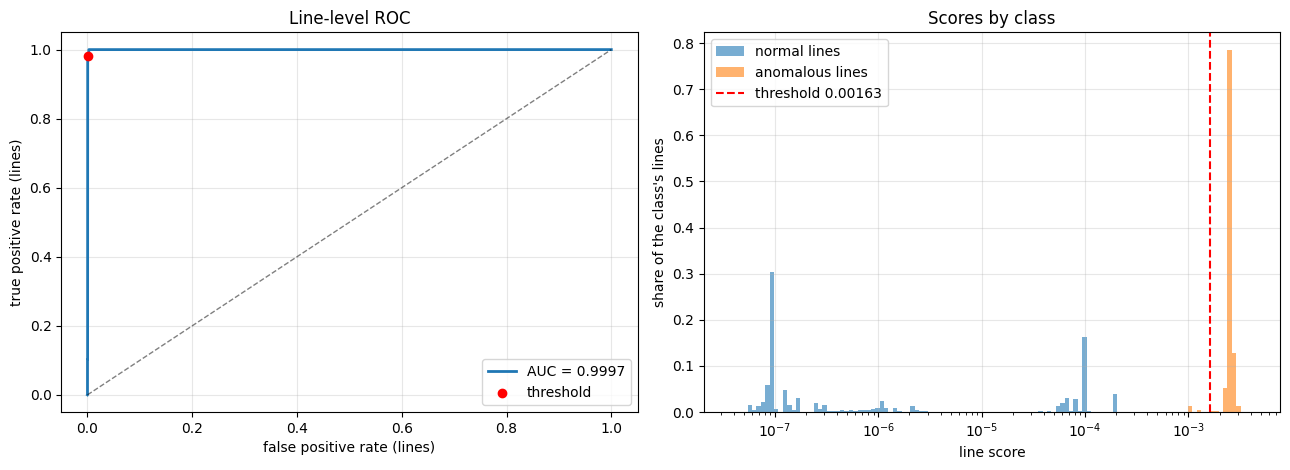

In [16]:
import matplotlib.pyplot as plt

order = np.argsort(-line_score)
tpr = np.cumsum(line_truth[order]) / line_truth.sum()
fpr = np.cumsum(~line_truth[order]) / (~line_truth).sum()
auc = float(np.trapz(tpr, fpr))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {auc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[0].scatter([m["FP"] / (~line_truth).sum()], [m["recall"]], color="red", zorder=5, label="threshold")
axes[0].set(xlabel="false positive rate (lines)", ylabel="true positive rate (lines)", title="Line-level ROC")
axes[0].legend()
axes[0].grid(alpha=0.3)

positive = line_score[line_score > 0]
bins = np.logspace(np.log10(positive.min()), np.log10(positive.max()), 120)
for cls, name in ((~line_truth, "normal lines"), (line_truth, "anomalous lines")):
    axes[1].hist(line_score[cls], bins=bins, alpha=0.6, weights=np.full(int(cls.sum()), 1 / cls.sum()), label=name)
axes[1].axvline(THRESHOLD, color="red", ls="--", label=f"threshold {THRESHOLD:.3g}")
axes[1].set(xscale="log", xlabel="line score", ylabel="share of the class's lines", title="Scores by class")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()